# 3.3. Validation: ToxPredictor model

### 📘 Overview

This notebook validates the ToxPredictor model using pathway-level signatures of unseen compounds as input to generate dose-resolved DILI risk probabilities and safety margins. 

**Inputs**
- Pathway-level signatures (–log₁₀ *p*-values per compound–dose)  
- Pretrained ToxPredictor model (random forest ensemble)  
- Clinical C<sub>max</sub> values for each compound–dose pair (for safety margin calculation)

**Output**  
- Predicted DILI risk probabilities for each compound and dose  
- Predicted safety margins 
- Validation metrics to assess model performance
- Clinical validation (**Figure 5**)

In [ ]:
%%capture

!pip install scikit-learn==1.4.0

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import dilimap as dmap
from dilimap.utils import groupby, crosstab

In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
dmap.logging.print_version()

Running dilimap 1.0.2 (python 3.10.16) on 2025-06-29 15:29.


## Pull validation data and map DILI labels

In [4]:
adata = dmap.s3.read('validation_data_pathways.h5ad')

Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


In [5]:
dmap.utils.map_dili_labels_and_cmax(adata)

Package: s3://dilimap/public/data. Top hash: e5bf3de9d2
Package: s3://dilimap/public/data. Top hash: e5bf3de9d2
Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


In [6]:
adata.obs.groupby('DILI_label', observed=True)['compound_name'].nunique()

DILI_label
DILI (few cases)     2
DILI (known)         4
DILI (likely)       15
DILI (withdrawn)    14
No DILI             14
Name: compound_name, dtype: int64

In [7]:
adata.obs.groupby('DILI_label_binary', observed=True)['compound_name'].nunique()

DILI_label_binary
DILI       33
No DILI    14
Name: compound_name, dtype: int64

## Model validation

In [8]:
model = dmap.models.ToxPredictor()

Package: s3://dilimap/public/models. Top hash: b119d5a238
Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


In [9]:
df_res = model.predict(adata)
df_res_margins = model.compute_safety_margin(adata)

283 out of 469 features in your data are not present in the training data. These features will not impact predictions. You can access the features available in the training data via `model.features`.
283 out of 469 features in your data are not present in the training data. These features will not impact predictions. You can access the features available in the training data via `model.features`.


In [10]:
df_res.head()

,DILI_probability
AKN-028,0.117463
AKN-028,0.353945
AKN-028,0.888980
AKN-028,0.883934
Almotriptan,0.000000


In [11]:
df_res_margins.head()

,Cmax_uM,First_DILI_uM,MOS_Cytotoxicity,MOS_ToxPredictor,Primary_DILI_driver,Classification
compound_name,,,,,,
AKN-028,1.000000,16.666667,300.000000,16.666667,Transcriptomics,+
Almotriptan,0.182730,NaN,300.000000,300.000000,none,-
Atomoxetine,1.597258,NaN,40.312844,40.312844,Cytotoxicity,+
BMS-986142,1.887880,3.703704,300.000000,1.961832,Transcriptomics,+
Bethanechol,1.612703,NaN,300.000000,300.000000,none,-


In [12]:
adata.obs['DILI_prob'] = df_res['DILI_probability']

df_res_margins['DILI_label'] = df_res_margins.index.map(
    groupby(adata, 'compound_name', aggfunc='first')['DILI_label']
)
df_res_margins = df_res_margins[
    df_res_margins.DILI_label.isin(
        ['DILI (withdrawn)', 'DILI (known)', 'DILI (likely)', 'No DILI']
    )
]
df_res_margins['DILI'] = df_res_margins['DILI_label'] != 'No DILI'

In [13]:
df_crosstab = crosstab(adata, ['compound_name', 'dose_level', 'DILI_prob'])[
    ['Low', 'Middle', 'Mid-High', 'High']
]
display(
    df_crosstab.style.format(precision=2).background_gradient(
        'RdBu_r', vmin=-0.2, vmax=1.25
    )
)

dose_level,Low,Middle,Mid-High,High
compound_name,,,,
AKN-028,0.12,0.35,0.89,0.88
Almotriptan,0.00,0.00,0.00,0.03
Atomoxetine,0.44,0.20,0.40,0.06
BMS-986142,0.89,0.86,0.90,0.88
Bethanechol,0.27,0.15,0.11,0.09
Bisacodyl,0.00,0.00,0.00,0.00
Bromfenac,0.33,0.44,0.47,0.45
Brompheniramine,0.00,0.00,0.00,0.01
Chlormezanone,0.14,0.64,0.91,0.92


In [14]:
df_res_margins[['MOS_ToxPredictor', 'DILI_label']]

,MOS_ToxPredictor,DILI_label
compound_name,,
AKN-028,16.666667,DILI (withdrawn)
Almotriptan,300.000000,No DILI
Atomoxetine,40.312844,DILI (likely)
BMS-986142,1.961832,DILI (withdrawn)
Bethanechol,300.000000,No DILI
Bisacodyl,300.000000,No DILI
Bromfenac,138.888889,DILI (withdrawn)
Brompheniramine,300.000000,No DILI
Chlormezanone,1.000000,DILI (withdrawn)


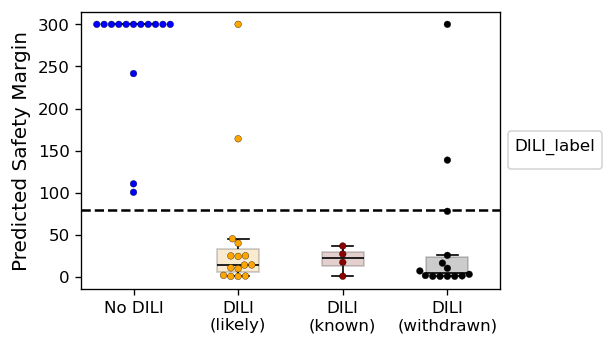

In [16]:
fig, ax = plt.subplots(figsize=(4.5, 3), dpi=120)
dmap.pl.boxplot_with_swarm(
    df_res_margins,
    box_width=0.4,
    swarm_size=4,
    x='DILI_label',
    y='MOS_ToxPredictor',
    hue_order=['No DILI', 'DILI (likely)', 'DILI (known)', 'DILI (withdrawn)'],
    palette=['blue', 'orange', 'darkred', 'k'],
    axhline=80,
    ylabel='Predicted Safety Margin',
    xlabel='',
)

In [17]:
df_res_margins['DILI_classified'] = df_res_margins['MOS_ToxPredictor'] < 80

df_tmps = {}

df_tmps['Sensitivity'] = df_res_margins[
    df_res_margins['DILI_label'].isin(
        ['DILI (withdrawn)', 'DILI (known)', 'DILI (likely)']
    )
]['DILI_classified']
df_tmps['Specificity'] = ~df_res_margins[
    df_res_margins['DILI_label'].isin(['No DILI'])
]['DILI_classified']
for k in ['DILI (withdrawn)', 'DILI (known)', 'DILI (likely)', 'DILI (few cases)']:
    df_tmps[k] = df_res_margins[df_res_margins['DILI_label'] == k]['DILI_classified']

for k, df_tmp in df_tmps.items():
    if len(df_tmp) > 0:
        print(
            f'{k}: {sum(df_tmp)} / {int(len(df_tmp))} ({int(np.mean(df_tmp) * 100)}%) '
        )

Sensitivity: 29 / 33 (87%) 
Specificity: 14 / 14 (100%) 
DILI (withdrawn): 12 / 14 (85%) 
DILI (known): 4 / 4 (100%) 
DILI (likely): 13 / 15 (86%) 


In [18]:
from sklearn.metrics import confusion_matrix, roc_auc_score

y_true = df_res_margins['DILI']
y_preds_strategies = ['MOS_Cytotoxicity < 120', 'MOS_ToxPredictor < 80']

for y_strat in y_preds_strategies:
    y_key, thresh = y_strat.split(' > ') if '>' in y_strat else y_strat.split(' < ')

    y_pred = df_res_margins[y_key]
    y_pred_bin = y_pred < float(thresh) if '<' in y_strat else y_pred > float(thresh)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_bin).ravel()

    print(
        f'\n{y_strat}:'
        f'\nAUC: {np.round(roc_auc_score(y_true, (-y_pred if "<" in y_strat else y_pred)), 2)}) '
        f'\nSensitivity: {tp}/{(tp + fn)} ({int(tp / (tp + fn) * 100)}%) '
        f'\nSpecificity: {tn}/{(tn + fp)} ({int(tn / (tn + fp) * 100)}%)'
    )


MOS_Cytotoxicity < 120:
AUC: 0.65) 
Sensitivity: 9/33 (27%) 
Specificity: 14/14 (100%)

MOS_ToxPredictor < 80:
AUC: 0.95) 
Sensitivity: 29/33 (87%) 
Specificity: 14/14 (100%)


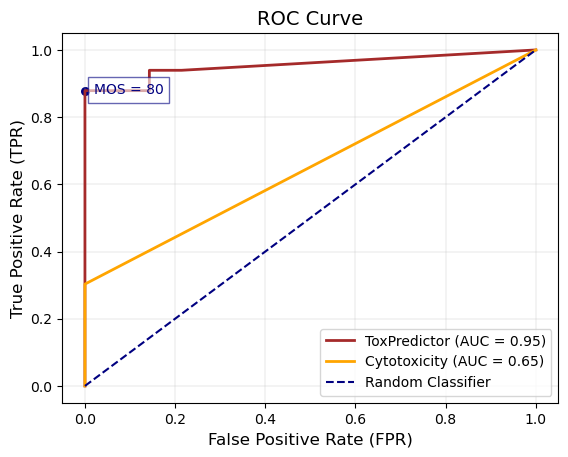

In [19]:
dmap.pl.roc_curve(
    df_res_margins['DILI'],
    df_res_margins['MOS_ToxPredictor'],
    threshold_points=[80],
    threshold_name='MOS',
    label='ToxPredictor',
    inverse=True,
    show=False,
)

dmap.pl.roc_curve(
    df_res_margins['DILI'],
    df_res_margins['MOS_Cytotoxicity'],
    label='Cytotoxicity',
    color='orange',
    inverse=True,
    show=True,
)

283 out of 469 features in your data are not present in the training data. These features will not impact predictions. You can access the features available in the training data via `model.features`.


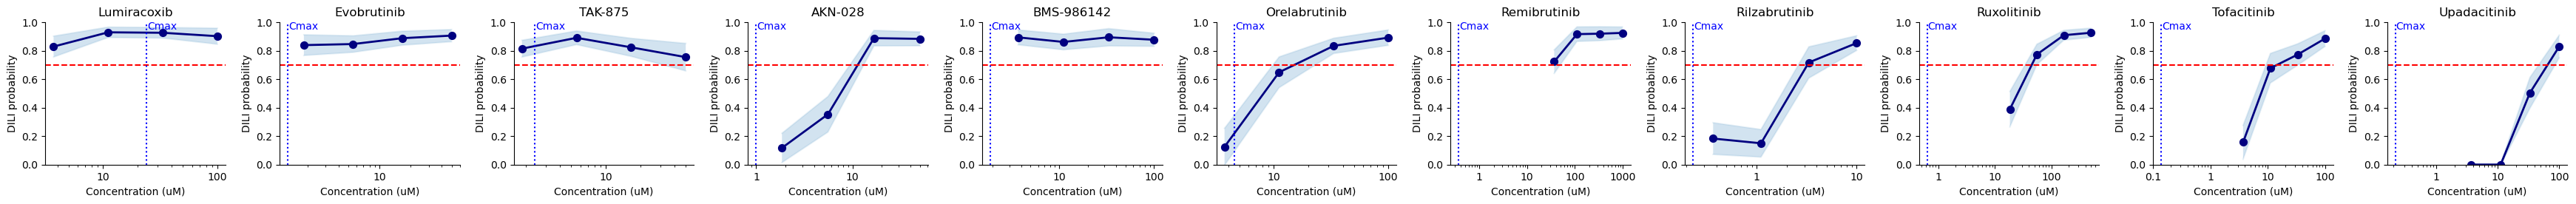

In [20]:
from matplotlib.ticker import FuncFormatter

adata.obs['DILI_prob_std'] = model.predict_proba_across_estimators(adata).std(1)

cmpds = [
    'Lumiracoxib',
    'Evobrutinib',
    'TAK-875',
    'AKN-028',
    'BMS-986142',
    'Orelabrutinib',
    'Remibrutinib',
    'Rilzabrutinib',
    'Ruxolitinib',
    'Tofacitinib',
    'Upadacitinib',
]
cmpds = [c for c in cmpds if c in adata.obs['compound_name'].values]

fig, axs = plt.subplots(
    1, len(cmpds), figsize=(4 * len(cmpds), 2.5), gridspec_kw={'wspace': 0.3}
)

for i, cmpd in enumerate(cmpds):
    adata_cmpd = adata[adata.obs['compound_name'] == cmpd]
    y_mean = adata_cmpd.obs['DILI_prob']
    y_std = adata_cmpd.obs['DILI_prob_std']

    error = y_std
    lower = y_mean - 2.576 * error
    upper = y_mean + 2.576 * error

    df = adata_cmpd.obs[['dose_uM', 'DILI_prob']]
    x = adata_cmpd.obs['dose_uM'].values

    axs[i].plot(x, lower, color='tab:blue', alpha=0.1)
    axs[i].plot(x, upper, color='tab:blue', alpha=0.1)
    axs[i].fill_between(x, lower, upper, alpha=0.2)

    axs[i].scatter(x, y_mean, color='navy', s=50)
    axs[i].plot(x, y_mean, label='DILI_prob', color='navy', linewidth=2)

    axs[i].set_xlabel('Concentration (uM)')
    axs[i].set_ylabel('DILI probability')
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    axs[i].axhline(0.7, linestyle='--', color='red')
    drug_cmax = adata_cmpd.obs['Cmax_uM'].iloc[0]
    if drug_cmax is not np.nan:
        axs[i].axvline(drug_cmax, linestyle=':', color='b')  #'-', '--', '-.',
        axs[i].annotate('Cmax', (drug_cmax * 1.02, 0.95), color='b')
    # axs[i].annotate('DILI cutoff', (np.min(x)*0.95, 0.72), c='red')

    axs[i].set_ylim(0, 1)
    axs[i].set_xscale('log')
    axs[i].set_title(cmpd)
    # ax.legend(loc='lower right')

    axs[i].xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: (
                '{{:.{:1d}f}}'.format(int(np.maximum(-np.log10(x), 0)))
            ).format(x)
        )
    )

plt.show()

## Clinical Validation

In [21]:
df_res_margins = model.compute_safety_margin(adata)

283 out of 469 features in your data are not present in the training data. These features will not impact predictions. You can access the features available in the training data via `model.features`.


In [22]:
cmpds = [
    'Evobrutinib',
    'TAK-875',
    'BMS-986142',
    'Orelabrutinib',
    'Remibrutinib',
    'Rilzabrutinib',
    'Tofacitinib',
    'Upadacitinib',
]
df_plot = df_res_margins.loc[cmpds].sort_values('MOS_ToxPredictor')

df_plot.index.name = None
df_plot.style.background_gradient()

,Cmax_uM,First_DILI_uM,MOS_Cytotoxicity,MOS_ToxPredictor,Primary_DILI_driver,Classification
TAK-875,2.382632,1.851852,83.940800,1.000000,Transcriptomics,+
Evobrutinib,1.292170,1.851000,300.000000,1.432474,Transcriptomics,+
BMS-986142,1.887880,3.703704,300.000000,1.961832,Transcriptomics,+
Orelabrutinib,4.509942,33.333333,221.732365,7.391079,Transcriptomics,+
Rilzabrutinib,0.232803,3.333333,300.000000,14.318280,Transcriptomics,+
Remibrutinib,0.368473,37.037037,300.000000,100.514953,none,-
Tofacitinib,0.137977,33.333333,300.000000,241.585460,none,-
Upadacitinib,0.215563,100.000000,300.000000,300.000000,none,-


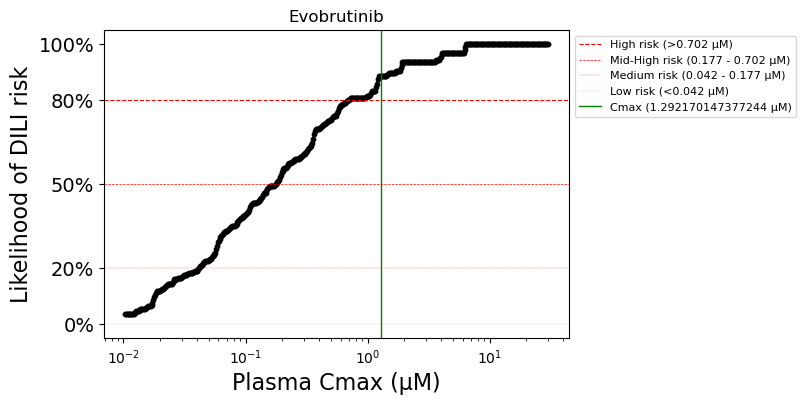

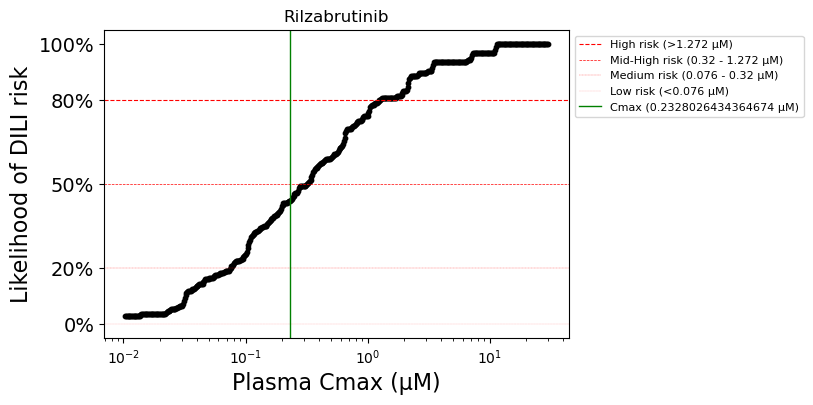

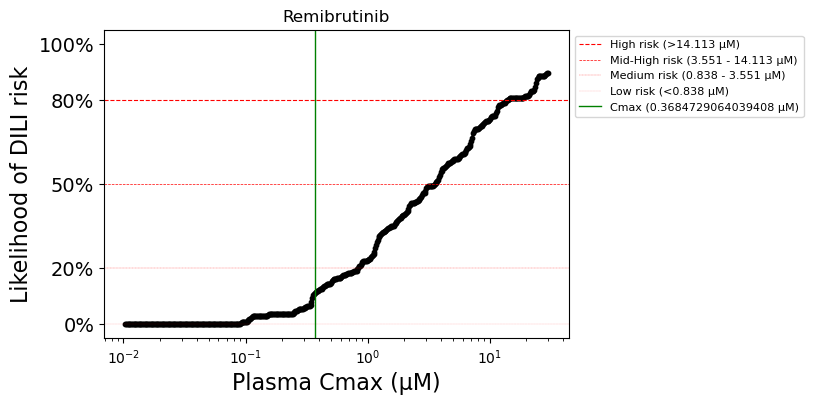

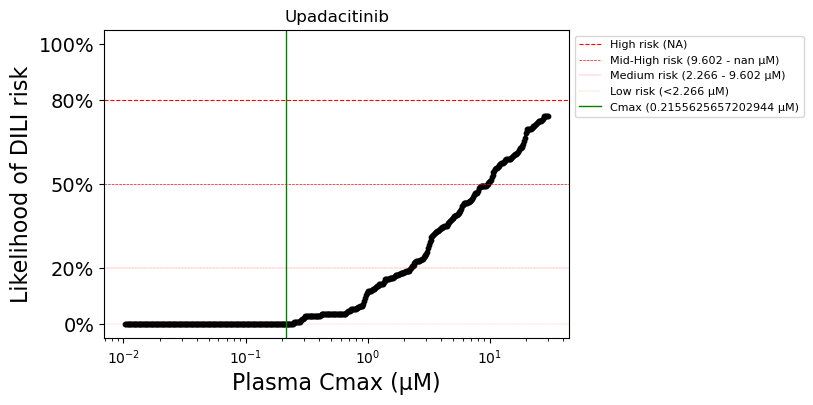

In [23]:
model.plot_DILI_dose_regimes('Evobrutinib', xmax=None, fontsize=16)
model.plot_DILI_dose_regimes('Rilzabrutinib', xmax=None, fontsize=16)
model.plot_DILI_dose_regimes('Remibrutinib', xmax=None, fontsize=16)
model.plot_DILI_dose_regimes('Upadacitinib', xmax=None, fontsize=16)